In [5]:
import pandas as pd

import pandas as pd

file_path = r"C:\Users\micha\OneDrive\Desktop\MSDS 420\Group Project\Charging Dataset\Electric and Alternative Fuel Charging Stations.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Preview
df.head()


C:\Users\micha\AppData\Local\Temp\ipykernel_23188\3272340060.py:8: DtypeWarning: Columns (6,16,20,31,33,36,39,40,41,43,46,52,53,55,57,58,60,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access
0,CNG,Spire - Montgomery Operations Center,2951 Chestnut St,NaN,Montgomery,AL,36107,NaN,NaN,E,...,NaN,NaN,NaN,NaN,B,3600,MD,NaN,NaN,NaN
1,CNG,PS Energy - Atlanta,340 Whitehall St,"From I-7585 N, exit 91 to Central Ave, left on...",Atlanta,GA,30303,NaN,770-350-3000,E,...,NaN,NaN,NaN,NaN,Q,3600,MD,NaN,NaN,False
2,CNG,Metropolitan Atlanta Rapid Transit Authority,2424 Piedmont Rd NE,NaN,Atlanta,GA,30324,NaN,NaN,E,...,NaN,NaN,NaN,NaN,Q,3000,LD,NaN,NaN,NaN
3,CNG,United Parcel Service,270 Marvin Miller Dr,NaN,Atlanta,GA,30336,NaN,NaN,E,...,NaN,NaN,NaN,NaN,B,3600,HD,NaN,NaN,NaN
4,CNG,Arkansas Oklahoma Gas Corp,2100 S Waldron Rd,NaN,Fort Smith,AR,72903,NaN,479-783-3188,E,...,NaN,NaN,NaN,NaN,Q,3600,MD,NaN,NaN,False


In [7]:
# Step 1: Filter to only electric stations
ev_df = df[df['Fuel Type Code'] == 'ELEC']

# Step 2: Further filter to only Illinois stations
ev_il_df = ev_df[ev_df['State'] == 'IL']

# Step 3: Check how many records and preview
print(ev_il_df.shape)
ev_il_df.columns
ev_il_df.info()

(1114, 65)
<class 'pandas.core.frame.DataFrame'>
Index: 1114 entries, 1763 to 70389
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Fuel Type Code                    1114 non-null   object 
 1   Station Name                      1114 non-null   object 
 2   Street Address                    1114 non-null   object 
 3   Intersection Directions           72 non-null     object 
 4   City                              1114 non-null   object 
 5   State                             1114 non-null   object 
 6   ZIP                               1114 non-null   object 
 7   Plus4                             0 non-null      float64
 8   Station Phone                     1023 non-null   object 
 9   Status Code                       1114 non-null   object 
 10  Expected Date                     1 non-null      object 
 11  Groups With Access Code           1114 non-null   object 
 

In [9]:
ev_il_df.head()
ev_il_df.columns
ev_il_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1114 entries, 1763 to 70389
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Fuel Type Code                    1114 non-null   object 
 1   Station Name                      1114 non-null   object 
 2   Street Address                    1114 non-null   object 
 3   Intersection Directions           72 non-null     object 
 4   City                              1114 non-null   object 
 5   State                             1114 non-null   object 
 6   ZIP                               1114 non-null   object 
 7   Plus4                             0 non-null      float64
 8   Station Phone                     1023 non-null   object 
 9   Status Code                       1114 non-null   object 
 10  Expected Date                     1 non-null      object 
 11  Groups With Access Code           1114 non-null   object 
 12  Access 

In [11]:
#Columns to Drop as they are completely empty or nearly empty 
cols_to_drop = [
    'Plus4', 'BD Blends', 'NG Fill Type Code', 'NG PSI',
    'Expected Date', 'Cards Accepted', 'EV Other Info',
    'Federal Agency ID', 'Federal Agency Name',
    'Hydrogen Status Link', 'NG Vehicle Class', 'LPG Primary',
    'E85 Blender Pump', 'Intersection Directions (French)',
    'Access Days Time (French)', 'BD Blends (French)',
    'Groups With Access Code (French)', 'Hydrogen Is Retail',
    'Federal Agency Code', 'CNG Dispenser Num', 'CNG On-Site Renewable Source',
    'CNG Total Compression Capacity', 'CNG Storage Capacity',
    'LNG On-Site Renewable Source', 'E85 Other Ethanol Blends',
    'EV Pricing (French)', 'LPG Nozzle Types', 'Hydrogen Pressures',
    'Hydrogen Standards', 'CNG Fill Type Code', 'CNG PSI',
    'CNG Vehicle Class', 'LNG Vehicle Class', 'EV On-Site Renewable Source'
]

# Drop columns from your Illinois EV dataset
ev_il_df = ev_il_df.drop(columns=cols_to_drop, errors = 'ignore')

# Check remaining shape and preview
print(ev_il_df.shape)
ev_il_df.head()


(1114, 31)


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Station Phone,Status Code,Groups With Access Code,...,Updated At,Owner Type Code,Open Date,EV Connector Types,Country,Access Code,Access Detail Code,Facility Type,EV Pricing,Restricted Access
1763,ELEC,City of Champaign - Hill Street Parking Deck,123 W Hill St,From Neil St head west on Hill or enter the de...,Champaign,IL,61820,217-403-4700,E,Public,...,2021-03-11 23:22:17 UTC,LG,2009-01-15,J1772,US,public,NaN,PAY_GARAGE,Free,False
2281,ELEC,INTERPARK 50 EAST OHIO 2,50 E Ohio St,NaN,Chicago,IL,60611,888-758-4389,E,Public,...,2022-07-25 00:40:27 UTC,NaN,2011-02-15,J1772 NEMA515,US,public,NaN,NaN,NaN,False
2478,ELEC,ComEd,3500 N California Ave,NaN,Chicago,IL,60618,NaN,E,Private,...,2021-11-01 03:01:01 UTC,T,2010-12-31,J1772,US,private,NaN,FLEET_GARAGE,NaN,NaN
2479,ELEC,ComEd,7601 S Lawndale Ave,NaN,Chicago,IL,60652,NaN,E,Private,...,2021-11-01 03:01:01 UTC,T,2010-12-31,J1772,US,private,NaN,FLEET_GARAGE,NaN,NaN
2480,ELEC,City Hall Annex - Town of Normal,100 E Phoenix Ave,"Right off Linden St, south side of police station",Normal,IL,61761,309-454-2444,E,Public,...,2022-02-10 19:42:29 UTC,LG,2011-04-15,J1772,US,public,NaN,MUNI_GOV,Free,False


In [32]:
# Fill NA with 0 for charger counts
for col in ['EV Level1 EVSE Num', 'EV Level2 EVSE Num', 'EV DC Fast Count']:
    ev_il_df[col] = ev_il_df[col].fillna(0)

# Create total chargers column
ev_il_df['Total Chargers'] = (
    ev_il_df['EV Level1 EVSE Num'] +
    ev_il_df['EV Level2 EVSE Num'] +
    ev_il_df['EV DC Fast Count']
)

# Check new shape and preview
print(ev_il_df.shape)
ev_il_df[['Station Name', 'City', 'ZIP', 'Total Chargers']].head()


(1114, 32)


,Station Name,City,ZIP,Total Chargers
1763,City of Champaign - Hill Street Parking Deck,Champaign,61820,4.0
2281,INTERPARK 50 EAST OHIO 2,Chicago,60611,2.0
2478,ComEd,Chicago,60618,14.0
2479,ComEd,Chicago,60652,26.0
2480,City Hall Annex - Town of Normal,Normal,61761,2.0


In [34]:
#Group by Zip to understand well-served vs underserved areas
zip_summary = (
    ev_il_df.groupby('ZIP')
    .agg({
        'Total Chargers': 'sum',
        'EV Level2 EVSE Num': 'sum',
        'EV DC Fast Count': 'sum',
        'Station Name': 'count'  # total stations
    })
    .rename(columns={'Station Name': 'Station Count'})
    .sort_values('Total Chargers', ascending=False)
)

zip_summary.head(10)


,Total Chargers,EV Level2 EVSE Num,EV DC Fast Count,Station Count
ZIP,,,,
60607,87.0,69.0,18.0,26
60611,85.0,83.0,1.0,37
60666,80.0,66.0,14.0,12
60088,63.0,40.0,0.0,5
60601,58.0,48.0,10.0,19
60523,54.0,45.0,9.0,19
60440,47.0,31.0,16.0,18
60606,43.0,43.0,0.0,22
60018,42.0,25.0,17.0,12


In [36]:
#Group by City to understand well-served vs underserved areas
city_summary = (
    ev_il_df.groupby('City')
    .agg({
        'Total Chargers': 'sum',
        'EV Level2 EVSE Num': 'sum',
        'EV DC Fast Count': 'sum',
        'Station Name': 'count'
    })
    .rename(columns={'Station Name': 'Station Count'})
    .sort_values('Total Chargers', ascending=False)
)

city_summary.head(10)


,Total Chargers,EV Level2 EVSE Num,EV DC Fast Count,Station Count
City,,,,
Chicago,801.0,697.0,102.0,277
Great Lakes,103.0,80.0,0.0,10
Evanston,62.0,49.0,13.0,27
Naperville,56.0,54.0,2.0,21
Normal,56.0,35.0,20.0,22
Aurora,54.0,37.0,17.0,16
Oak Brook,54.0,45.0,9.0,19
Bolingbrook,49.0,33.0,16.0,19
Skokie,46.0,19.0,27.0,10


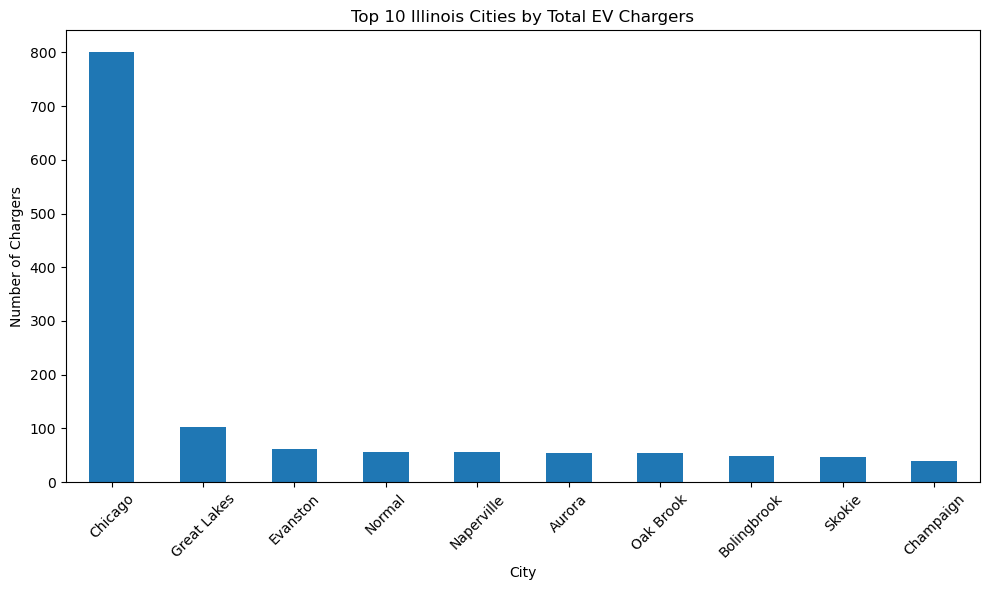

In [38]:
#plot the data 
import matplotlib.pyplot as plt

# Bar plot: Top 10 cities by total chargers
top_cities = city_summary.sort_values('Total Chargers', ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_cities['Total Chargers'].plot(kind='bar')
plt.title('Top 10 Illinois Cities by Total EV Chargers')
plt.ylabel('Number of Chargers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


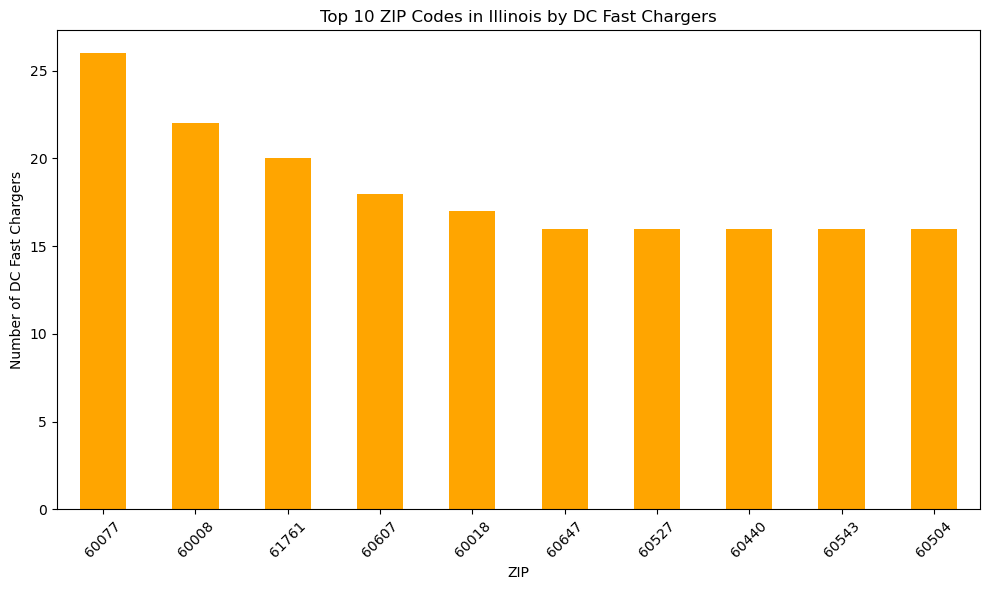

In [44]:
#Where are high-dwell-time chargers already placed (ideal for food/retail)?
top_dc_zip = zip_summary.sort_values('EV DC Fast Count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_dc_zip['EV DC Fast Count'].plot(kind='bar', color='orange')
plt.title('Top 10 ZIP Codes in Illinois by DC Fast Chargers')
plt.ylabel('Number of DC Fast Chargers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [64]:
#Will compare these with the registration to see if any of these zips have hight demand
low_zip_counts = zip_summary[zip_summary['Total Chargers'] <= 2]
low_zip_counts.shape[0]
low_zip_counts.sort_values('Total Chargers').head(10)


,Total Chargers,EV Level2 EVSE Num,EV DC Fast Count,Station Count,ZIP_City
ZIP,,,,,
61028,1.0,1.0,0.0,1,61028 - Elizabeth
61048,1.0,1.0,0.0,1,61048 - Lena
61401,1.0,1.0,0.0,1,61401 - Galesburg
61455,1.0,1.0,0.0,1,61455 - Macomb
60630,1.0,1.0,0.0,1,60630 - Chicago
61614,1.0,1.0,0.0,1,61614 - Peoria
61832,1.0,1.0,0.0,1,61832 - Danville
61834,1.0,1.0,0.0,1,61834 - Danville
62801,1.0,1.0,0.0,1,62801 - Centralia


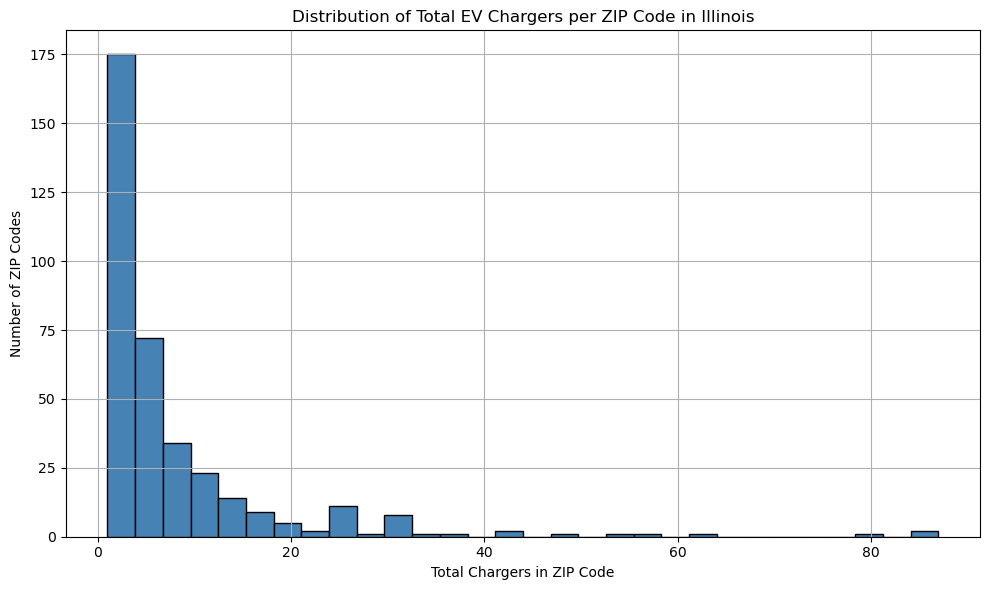

In [62]:
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(zip_summary['Total Chargers'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Total EV Chargers per ZIP Code in Illinois')
plt.xlabel('Total Chargers in ZIP Code')
plt.ylabel('Number of ZIP Codes')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
##“While over 100 ZIPs have at least one charger, the vast majority have just 1–3 — and only a handful have more than 10. 
#This indicates widespread coverage gaps and opportunity zones for new chargers or plaza build-outs.

In [70]:
#Access types Public V Private 
print(ev_il_df['Access Code'].value_counts())
ev_il_df.groupby('Access Code')['Total Chargers'].sum()


Access Code
public     1006
private     108
Name: count, dtype: int64


Access Code
private     339.0
public     2509.0
Name: Total Chargers, dtype: float64

In [ ]:
#The vast majority of charging access in Illinois is public-facing, which is promising for equitable EV adoption. 
#However, private stations still house over 1 in 10 chargers, which means certain charger capacity may be inaccessible to the general population — 
#a factor to consider when evaluating true availability and demand coverage.

In [72]:
#Status code check, all but one are operational
ev_il_df['Status Code'].value_counts()


Status Code
E    1113
T       1
Name: count, dtype: int64

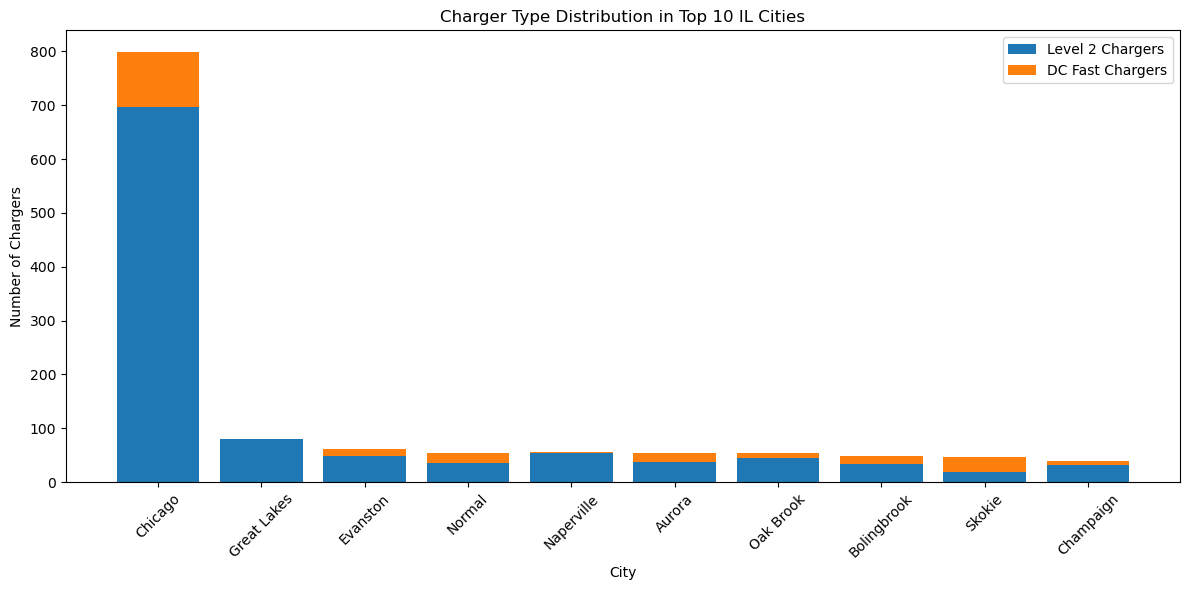

In [74]:
# Plotting
plt.figure(figsize=(12, 6))
plt.bar(top_cities.index, top_cities['EV Level2 EVSE Num'], label='Level 2 Chargers')
plt.bar(top_cities.index, top_cities['EV DC Fast Count'], bottom=top_cities['EV Level2 EVSE Num'], label='DC Fast Chargers')

plt.xlabel('City')
plt.ylabel('Number of Chargers')
plt.title('Charger Type Distribution in Top 10 IL Cities')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
##While Illinois’ top cities have built strong EV infrastructure, DC Fast chargers remain underrepresented in most areas outside of Chicago. 
#This highlights a strategic opportunity for gas station companies to differentiate with high-speed chargers, 
#especially in cities where wait times may be a concern.

In [80]:
charger_ratios = ev_il_df.groupby('ZIP').agg({
    'EV Level2 EVSE Num': 'sum',
    'EV DC Fast Count': 'sum'
}).assign(dc_fast_ratio=lambda df: df['EV DC Fast Count'] / (df['EV Level2 EVSE Num'] + 1))
print(charger_ratios)

       EV Level2 EVSE Num  EV DC Fast Count  dc_fast_ratio
ZIP                                                       
60004                 2.0               1.0       0.333333
60005                 2.0               0.0       0.000000
60014                 2.0               0.0       0.000000
60016                 2.0               0.0       0.000000
60018                 2.0               0.0       0.000000
...                   ...               ...            ...
62881                 3.0               0.0       0.000000
62947                 2.0               0.0       0.000000
62958                 4.0               0.0       0.000000
62959                 0.0               8.0       8.000000
65063                10.0               0.0       0.000000

[365 rows x 3 columns]


In [76]:
import folium
from folium.plugins import MarkerCluster

# Fill missing charger counts with 0
ev_il_df['EV DC Fast Count'] = ev_il_df['EV DC Fast Count'].fillna(0)
ev_il_df['EV Level2 EVSE Num'] = ev_il_df['EV Level2 EVSE Num'].fillna(0)

# Create map centered over Illinois
m = folium.Map(location=[40.0, -89.0], zoom_start=6)

# Create marker cluster
marker_cluster = MarkerCluster().add_to(m)

# Add markers
for _, row in ev_il_df.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    name = row['Station Name']
    address = row['Street Address']
    city = row['City']
    zip_code = row['ZIP']
    dc_fast = int(row['EV DC Fast Count'])
    level2 = int(row['EV Level2 EVSE Num'])
    
    popup_text = f"""
    <b>{name}</b><br>
    {address}, {city}, IL {zip_code}<br>
    Level 2 Chargers: {level2}<br>
    DC Fast Chargers: {dc_fast}
    """
    
    # Color based on presence of DC Fast
    color = 'green' if dc_fast > 0 else 'blue'
    
    folium.Marker(
        location=[lat, lon],
        popup=popup_text,
        icon=folium.Icon(color=color)
    ).add_to(marker_cluster)

# Save map
m.save("illinois_ev_chargers_map.html")


<Axes: ylabel='Facility Type'>

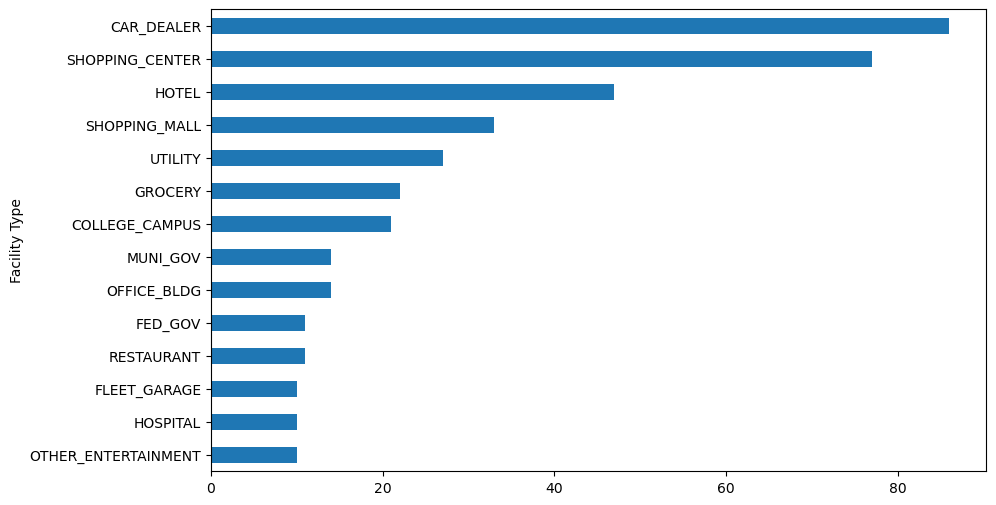

In [84]:
facility_counts = ev_il_df['Facility Type'].value_counts()
filtered_counts = facility_counts[facility_counts >= 10]
filtered_counts.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6))


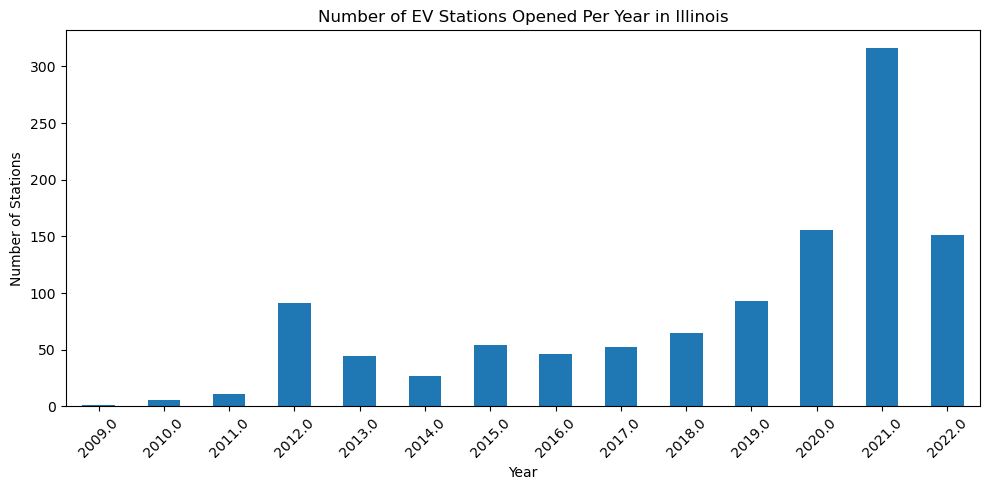

Timestamp('2022-07-23 00:00:00')

In [99]:
# Convert Open Date to datetime
ev_il_df['Open Date'] = pd.to_datetime(ev_il_df['Open Date'], errors='coerce')

# Extract year from Open Date
ev_il_df['Open Year'] = ev_il_df['Open Date'].dt.year

# Drop null years if any, then group and plot
ev_il_df['Open Year'].dropna().value_counts().sort_index().plot(kind='bar', figsize=(10, 5))
plt.title('Number of EV Stations Opened Per Year in Illinois')
plt.xlabel('Year')
plt.ylabel('Number of Stations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
ev_il_df['Open Date'].max()




In [135]:
# Step 2: Filter for non-electric stations in Illinois
non_elec_df = df[(df['Fuel Type Code'] != 'ELEC') & (df['State'] == 'IL')]

# Step 3: Group both datasets by ZIP
non_elec_counts = non_elec_df.groupby("ZIP").size().reset_index(name="Non-Electric Station Count")
elec_counts = ev_il_df.groupby("ZIP").size().reset_index(name="Electric Station Count")

# Step 4: Merge and identify ZIPs with non-EV stations but no EV stations
merged = pd.merge(non_elec_counts, elec_counts, on="ZIP", how="left").fillna(0)
merged["Electric Station Count"] = merged["Electric Station Count"].astype(int)
no_ev_zips = merged[merged["Electric Station Count"] == 0]

# Step 5: Add city information (take first city per ZIP from non_elec_df)
zip_city_map = non_elec_df[['ZIP', 'City']].drop_duplicates(subset='ZIP')
no_ev_zips = no_ev_zips.merge(zip_city_map, on='ZIP', how='left')

# Step 6: Display top ZIPs that already have stations but no EV support
no_ev_zips.sort_values("Non-Electric Station Count", ascending=False).head(20)

,ZIP,Non-Electric Station Count,Electric Station Count,City
67,60804,5,0,Cicero
118,62702,4,0,Springfield
30,60440,4,0,Bolingbrook
9,60088,3,0,Great Lakes
180,61071,3,0,Rock Falls
20,60185,3,0,West Chicago
42,60491,3,0,Homer Glen
106,62225,3,0,Scott AFB
159,60544,3,0,Plainfield
181,61073,3,0,Roscoe


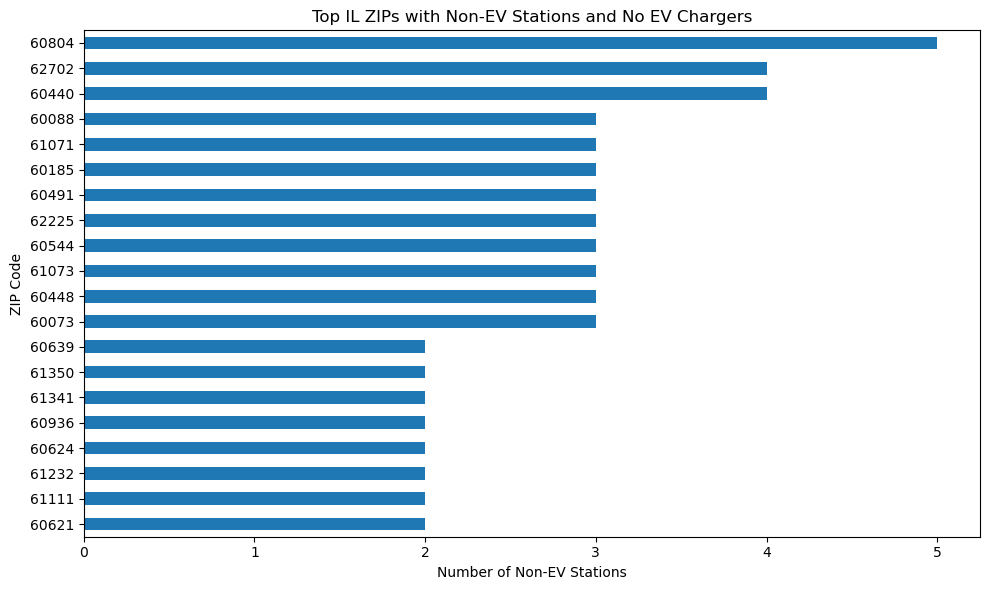

In [119]:
# Filter to only non-EV stations in IL
non_elec_il_df = df[(df['Fuel Type Code'] != 'ELEC') & (df['State'] == 'IL')]

# Identify ZIPs in IL with no EV chargers
zips_with_ev = ev_il_df['ZIP'].unique()
non_ev_zip_summary = non_elec_il_df[~non_elec_il_df['ZIP'].isin(zips_with_ev)] \
    .groupby('ZIP') \
    .size() \
    .sort_values(ascending=False).head(20)

# Plot ZIP-level
plt.figure(figsize=(10, 6))
non_ev_zip_summary.plot(kind='barh')
plt.xlabel("Number of Non-EV Stations")
plt.ylabel("ZIP Code")
plt.title("Top IL ZIPs with Non-EV Stations and No EV Chargers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


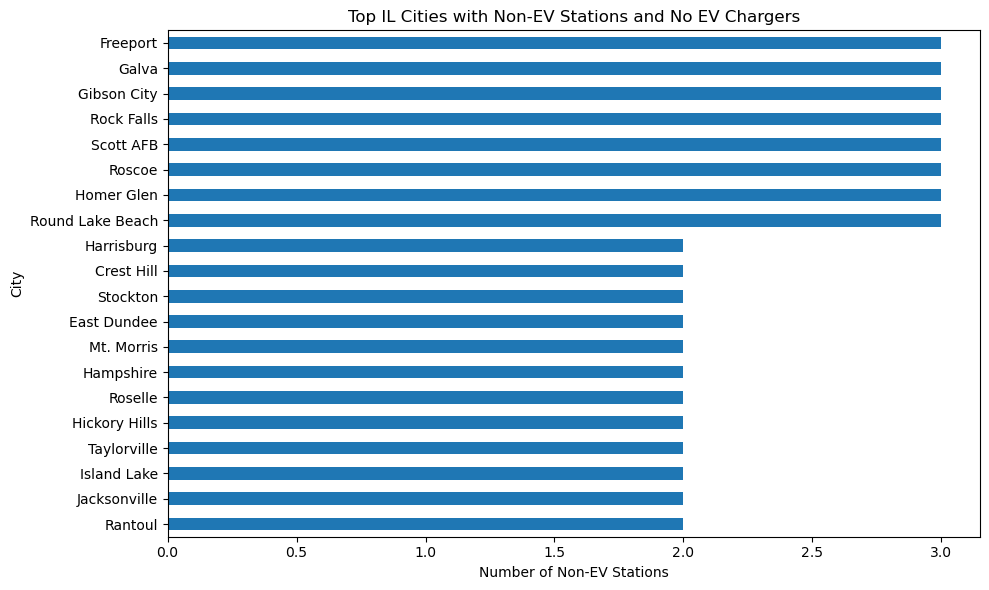

In [121]:
# Identify Cities in IL with no EV chargers
cities_with_ev = ev_il_df['City'].str.upper().unique()
non_ev_city_summary = non_elec_il_df[~non_elec_il_df['City'].str.upper().isin(cities_with_ev)] \
    .groupby('City') \
    .size() \
    .sort_values(ascending=False).head(20)

# Plot City-level
plt.figure(figsize=(10, 6))
non_ev_city_summary.plot(kind='barh')
plt.xlabel("Number of Non-EV Stations")
plt.ylabel("City")
plt.title("Top IL Cities with Non-EV Stations and No EV Chargers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

